# Modelos del clasificador 

Aqui se Genereraran los pesos de los modelos usados en el clasificador 

In [1]:
import random
import time
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, f1_score

plt.style.use('seaborn-v0_8')

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

Dispositivo: cpu


## Metricas del modelo

In [3]:
#graficas de las metricas del modelo
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['valid_loss'], label='valid')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='train')
    axes[1].plot(epochs, history['valid_acc'], label='valid')
    axes[1].set_title('Accuracy')
    axes[1].legend()

    axes[2].plot(epochs, history['train_f1'], label='train')
    axes[2].plot(epochs, history['valid_f1'], label='valid')
    axes[2].set_title('Macro-F1')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

In [4]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds, targets = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        pred = logits.argmax(dim=1).cpu().numpy()
        preds.extend(pred.tolist())
        targets.extend(labels.numpy().tolist())
    return np.array(preds), np.array(targets)

def predicts(model):
    test_preds, test_targets = predict_loader(model, dataloaders['test'])
    test_acc = (test_preds == test_targets).mean()
    test_f1 = f1_score(test_targets, test_preds, average='macro')

    print(f'Test accuracy: {test_acc:.4f}')
    print(f'Test macro-F1: {test_f1:.4f}')
    print('\nClassification report (test):')
    print(classification_report(test_targets, test_preds, target_names=class_names))

    return test_preds, test_targets

In [5]:
def matriz_confusion(test_targets, test_preds):
    cm = confusion_matrix(test_targets, test_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
    ax.set_title('Matriz de confusion - Test')

    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## Seccion de Imagenes


In [6]:
DATA_DIR = Path("Dog's skin diseases-Kaggle_v_corta")
assert DATA_DIR.exists(), f'No se encontro la carpeta: {DATA_DIR.resolve()}'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

datasets_map = {
    'train': datasets.ImageFolder(DATA_DIR / 'train', transform=train_tfms),
    'valid': datasets.ImageFolder(DATA_DIR / 'valid', transform=eval_tfms),
    'test': datasets.ImageFolder(DATA_DIR / 'test', transform=eval_tfms),
}

dataloaders = {
    split: DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=(split == 'train'),
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == 'cuda')
    )
    for split, ds in datasets_map.items()
}

class_names = datasets_map['train'].classes
num_classes = len(class_names)

print('Clases:', class_names)
print('Tamano train/valid/test:', len(datasets_map['train']), len(datasets_map['valid']), len(datasets_map['test']))

Clases: ['Demodicosis', 'Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'Ringworm']
Tamano train/valid/test: 1258 370 183


In [7]:
targets = np.array(datasets_map['train'].targets)
class_counts = np.bincount(targets, minlength=num_classes)
class_weights = class_counts.sum() / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

for i, c in enumerate(class_names):
    print(f'{c}: n={class_counts[i]}, weight={class_weights[i].item():.4f}')

Demodicosis: n=210, weight=0.9984
Dermatitis: n=210, weight=0.9984
Fungal_infections: n=210, weight=0.9984
Healthy: n=204, weight=1.0278
Hypersensitivity: n=210, weight=0.9984
Ringworm: n=214, weight=0.9798


In [8]:
#función de Entrenamiento
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    running_loss, running_correct, n_samples = 0.0, 0, 0
    all_preds, all_targets = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        preds = logits.argmax(dim=1)
        bs = labels.size(0)

        running_loss += loss.item() * bs
        running_correct += (preds == labels).sum().item()
        n_samples += bs

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / n_samples
    epoch_acc = running_correct / n_samples
    epoch_f1 = f1_score(all_targets, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1


def train_with_early_stopping(model, train_loader, valid_loader, criterion, optimizer, scheduler, epochs=10, patience=4, phase_name='phase'):
    best_state = copy.deepcopy(model.state_dict())
    best_valid_f1 = -1.0
    best_epoch = -1
    wait = 0

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'valid_loss': [], 'valid_acc': [], 'valid_f1': [],
        'lr': []
    }

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        valid_loss, valid_acc, valid_f1 = run_epoch(model, valid_loader, criterion, optimizer=None)

        scheduler.step(valid_f1)
        lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['valid_loss'].append(valid_loss)
        history['valid_acc'].append(valid_acc)
        history['valid_f1'].append(valid_f1)
        history['lr'].append(lr)

        print(
            f'[{phase_name}] Epoch {epoch:02d}/{epochs} | '
            f'train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | '
            f'valid loss {valid_loss:.4f} acc {valid_acc:.4f} f1 {valid_f1:.4f} | '
            f'lr {lr:.2e}'
        )

        if valid_f1 > best_valid_f1:
            best_valid_f1 = valid_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f'[{phase_name}] Early stopping en epoch {epoch}.')
            break

    elapsed = (time.time() - t0) / 60
    model.load_state_dict(best_state)

    print(f'[{phase_name}] Mejor epoch: {best_epoch} | Mejor valid macro-F1: {best_valid_f1:.4f} | Tiempo: {elapsed:.2f} min')
    return model, history, best_valid_f1

## Modelo EficcientNet B0

In [9]:
def build_efficientnet_b0(num_classes):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

def freeze_backbone(model):
    for p in model.features.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True


def unfreeze_top_blocks(model, n_blocks=3):
    # Congela todo backbone primero
    for p in model.features.parameters():
        p.requires_grad = False

    # Descongela ultimos bloques de features
    children = list(model.features.children())
    for block in children[-n_blocks:]:
        for p in block.parameters():
            p.requires_grad = True

    # Clasificador siempre entrenable
    for p in model.classifier.parameters():
        p.requires_grad = True



In [10]:
model_efficientNet_mod = build_efficientnet_b0(num_classes).to(device)
freeze_backbone(model_efficientNet_mod)
model_efficientNet_mod

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [11]:
def trainable_params_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Parametros entrenables actuales:', trainable_params_count(model_efficientNet_mod))

Parametros entrenables actuales: 7686


In [12]:
# Etapa 1: descongelando el clasificador
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer_stage1 = optim.AdamW(
    [p for p in model_efficientNet_mod.parameters() if p.requires_grad],
    lr=5e-4,
    weight_decay=1e-4
)
scheduler_stage1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage1, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

model_efficientNet_mod, hist_stage1, best_f1_stage1 = train_with_early_stopping(
    model=model_efficientNet_mod,
    train_loader=dataloaders['train'],
    valid_loader=dataloaders['valid'],
    criterion=criterion,
    optimizer=optimizer_stage1,
    scheduler=scheduler_stage1,
    epochs=15,
    patience=3,
    phase_name='stage1-head'
)

[stage1-head] Epoch 01/15 | train loss 1.6151 acc 0.4173 f1 0.4139 | valid loss 1.4099 acc 0.6000 f1 0.5807 | lr 5.00e-04
[stage1-head] Epoch 02/15 | train loss 1.2841 acc 0.6630 f1 0.6572 | valid loss 1.1870 acc 0.6838 f1 0.6634 | lr 5.00e-04
[stage1-head] Epoch 03/15 | train loss 1.1119 acc 0.7067 f1 0.7028 | valid loss 1.0873 acc 0.7000 f1 0.6854 | lr 5.00e-04
[stage1-head] Epoch 04/15 | train loss 1.0198 acc 0.7377 f1 0.7333 | valid loss 1.0190 acc 0.7189 f1 0.7049 | lr 5.00e-04
[stage1-head] Epoch 05/15 | train loss 0.9545 acc 0.7464 f1 0.7445 | valid loss 0.9715 acc 0.7216 f1 0.7133 | lr 5.00e-04
[stage1-head] Epoch 06/15 | train loss 0.9264 acc 0.7576 f1 0.7551 | valid loss 0.9332 acc 0.7432 f1 0.7314 | lr 5.00e-04
[stage1-head] Epoch 07/15 | train loss 0.8841 acc 0.7663 f1 0.7651 | valid loss 0.9009 acc 0.7541 f1 0.7485 | lr 5.00e-04
[stage1-head] Epoch 08/15 | train loss 0.8526 acc 0.7750 f1 0.7734 | valid loss 0.8668 acc 0.7568 f1 0.7469 | lr 5.00e-04
[stage1-head] Epoch 09/1

In [13]:
# guardar el modelo 
model_path = "models/model_EfficientNet_15_epochs.pth"
torch.save(model_efficientNet_mod.state_dict(), model_path)

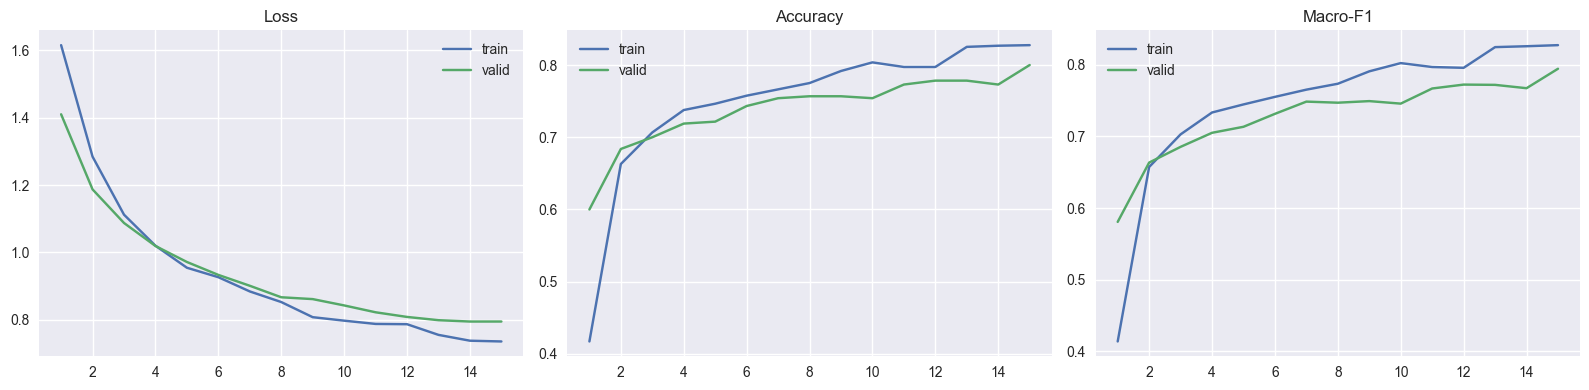

In [14]:
plot_history(hist_stage1)

Test accuracy: 0.8087
Test macro-F1: 0.8066

Classification report (test):
                   precision    recall  f1-score   support

      Demodicosis       0.90      0.87      0.89        31
       Dermatitis       0.88      0.68      0.76        31
Fungal_infections       0.74      0.79      0.77        29
          Healthy       0.86      0.97      0.91        31
 Hypersensitivity       0.69      0.76      0.72        29
         Ringworm       0.81      0.78      0.79        32

         accuracy                           0.81       183
        macro avg       0.81      0.81      0.81       183
     weighted avg       0.81      0.81      0.81       183



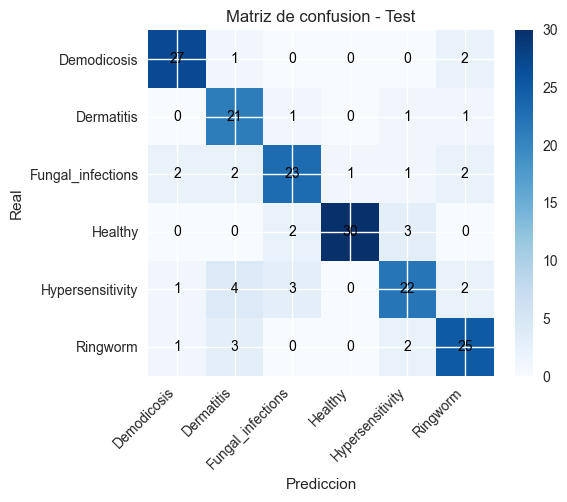

In [15]:
test_preds_EfficientNet, test_targets_EfficientNet = predicts(model_efficientNet_mod)
matriz_confusion(test_preds_EfficientNet, test_targets_EfficientNet)

## Modelo Mobilenet_v3

In [18]:
#cargamos el modelo MobileNet V3
def build_mobilenet_v3(num_classes):
    weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model = models.mobilenet_v3_small(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

model_mobilenet_v3_mod = build_mobilenet_v3(num_classes).to(device)
freeze_backbone(model_mobilenet_v3_mod)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\richi/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 11.5MB/s]


In [19]:
#visualizamos el modelo 
model_mobilenet_v3_mod

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16

In [20]:
#Entrenamos el modelo 
# Etapa 1 MobileNet: descongelando el clasificador
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer_stage1 = optim.AdamW(
    [p for p in model_mobilenet_v3_mod.parameters() if p.requires_grad],
    lr=5e-4,
    weight_decay=1e-4
)
scheduler_stage1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage1, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

model_mobilenet_v3_mod, hist_MobileNet, best_f1_MobilNet = train_with_early_stopping(
    model=model_mobilenet_v3_mod,
    train_loader=dataloaders['train'],
    valid_loader=dataloaders['valid'],
    criterion=criterion,
    optimizer=optimizer_stage1,
    scheduler=scheduler_stage1,
    epochs=12,
    patience=3,
    phase_name='stage1-head'
)

[stage1-head] Epoch 01/12 | train loss 1.3266 acc 0.5191 f1 0.5120 | valid loss 1.1310 acc 0.5730 f1 0.5564 | lr 5.00e-04
[stage1-head] Epoch 02/12 | train loss 0.9610 acc 0.6908 f1 0.6859 | valid loss 0.9786 acc 0.6946 f1 0.6886 | lr 5.00e-04
[stage1-head] Epoch 03/12 | train loss 0.8592 acc 0.7504 f1 0.7503 | valid loss 0.8750 acc 0.7216 f1 0.7138 | lr 5.00e-04
[stage1-head] Epoch 04/12 | train loss 0.7887 acc 0.7862 f1 0.7852 | valid loss 0.8323 acc 0.7892 f1 0.7910 | lr 5.00e-04
[stage1-head] Epoch 05/12 | train loss 0.7369 acc 0.7973 f1 0.7968 | valid loss 0.8253 acc 0.7730 f1 0.7673 | lr 5.00e-04
[stage1-head] Epoch 06/12 | train loss 0.6898 acc 0.8355 f1 0.8348 | valid loss 0.7693 acc 0.8243 f1 0.8231 | lr 5.00e-04
[stage1-head] Epoch 07/12 | train loss 0.6465 acc 0.8506 f1 0.8507 | valid loss 0.7453 acc 0.8162 f1 0.8150 | lr 5.00e-04
[stage1-head] Epoch 08/12 | train loss 0.6214 acc 0.8760 f1 0.8763 | valid loss 0.7695 acc 0.8054 f1 0.8001 | lr 5.00e-04
[stage1-head] Epoch 09/1

In [21]:
# guardar el modelo 
model_path = "models/mobilenet_v3_12_epochs.pth"
torch.save(model_mobilenet_v3_mod.state_dict(), model_path)

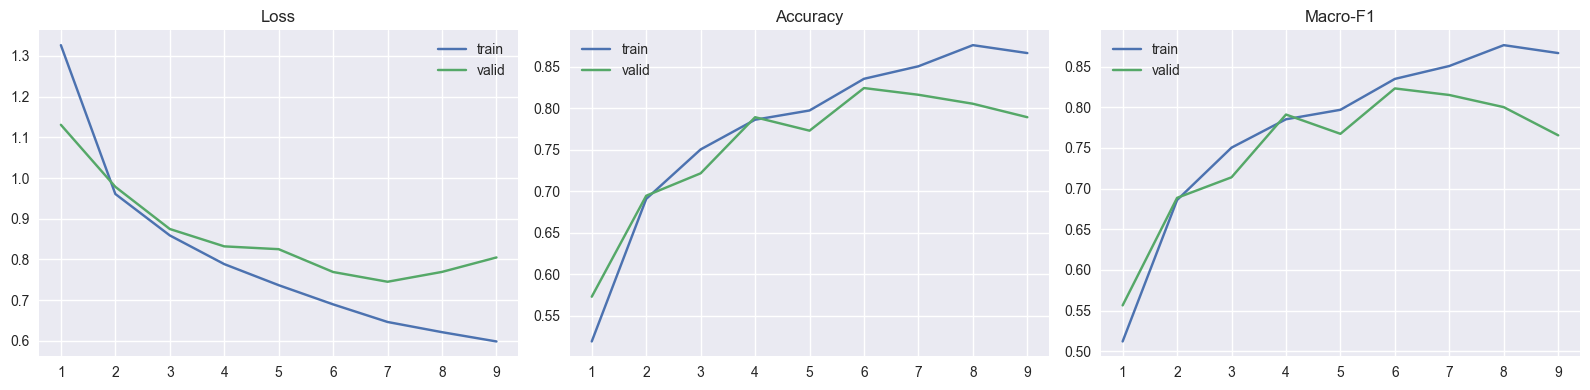

Test accuracy: 0.7978
Test macro-F1: 0.7992

Classification report (test):
                   precision    recall  f1-score   support

      Demodicosis       0.86      0.81      0.83        31
       Dermatitis       0.85      0.71      0.77        31
Fungal_infections       0.61      0.79      0.69        29
          Healthy       0.87      0.84      0.85        31
 Hypersensitivity       0.77      0.79      0.78        29
         Ringworm       0.90      0.84      0.87        32

         accuracy                           0.80       183
        macro avg       0.81      0.80      0.80       183
     weighted avg       0.81      0.80      0.80       183



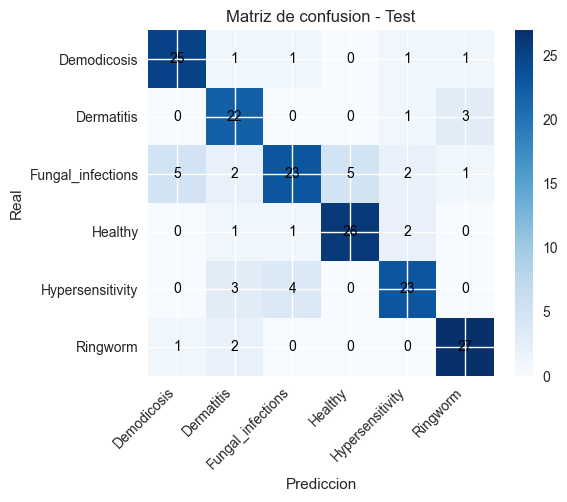

In [22]:
plot_history(hist_MobileNet)
test_preds_MobileNet, test_targets_MobileNet = predicts(model_mobilenet_v3_mod)
matriz_confusion(test_preds_MobileNet, test_targets_MobileNet)

## Resnet18


In [28]:
model_resnet18 = models.resnet18(pretrained=True)
model_aux = nn.Sequential(*list(model_resnet18.children())[:-1])
for i, parameter in enumerate(model_aux.parameters()):
  parameter.requires_grad = False

c:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [29]:
model_resnet18_mod = nn.Sequential(model_aux,
                       nn.Flatten(),
                       nn.Linear(in_features=512, out_features=6, bias= True))

In [31]:
#Entrenamos el modelo 
# Etapa 1 MobileNet: descongelando el clasificador
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer_stage1 = optim.AdamW(
    [p for p in model_resnet18_mod.parameters() if p.requires_grad],
    lr=5e-4,
    weight_decay=1e-4
)
scheduler_stage1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage1, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

model_resnet18_mod, hist_Resnet18, best_f1_Resnet18 = train_with_early_stopping(
    model=model_resnet18_mod,
    train_loader=dataloaders['train'],
    valid_loader=dataloaders['valid'],
    criterion=criterion,
    optimizer=optimizer_stage1,
    scheduler=scheduler_stage1,
    epochs=15,
    patience=3,
    phase_name='stage1-head'
)

[stage1-head] Epoch 01/15 | train loss 0.8781 acc 0.7496 f1 0.7474 | valid loss 0.9611 acc 0.6811 f1 0.6771 | lr 5.00e-04
[stage1-head] Epoch 02/15 | train loss 0.8487 acc 0.7727 f1 0.7722 | valid loss 0.9648 acc 0.6730 f1 0.6742 | lr 5.00e-04
[stage1-head] Epoch 03/15 | train loss 0.8306 acc 0.7742 f1 0.7734 | valid loss 0.9808 acc 0.6730 f1 0.6702 | lr 5.00e-04
[stage1-head] Epoch 04/15 | train loss 0.8265 acc 0.7663 f1 0.7649 | valid loss 0.9295 acc 0.6838 f1 0.6800 | lr 5.00e-04
[stage1-head] Epoch 05/15 | train loss 0.8070 acc 0.7814 f1 0.7801 | valid loss 0.9173 acc 0.6865 f1 0.6826 | lr 5.00e-04
[stage1-head] Epoch 06/15 | train loss 0.8181 acc 0.7639 f1 0.7618 | valid loss 0.9558 acc 0.6838 f1 0.6848 | lr 5.00e-04
[stage1-head] Epoch 07/15 | train loss 0.8035 acc 0.7790 f1 0.7775 | valid loss 0.9055 acc 0.6865 f1 0.6844 | lr 5.00e-04
[stage1-head] Epoch 08/15 | train loss 0.8012 acc 0.7782 f1 0.7783 | valid loss 0.9063 acc 0.7162 f1 0.7107 | lr 5.00e-04
[stage1-head] Epoch 09/1

In [32]:
# guardar el modelo 
model_path = "models/Resnet18_mod.pth"
torch.save(model_resnet18_mod.state_dict(), model_path)

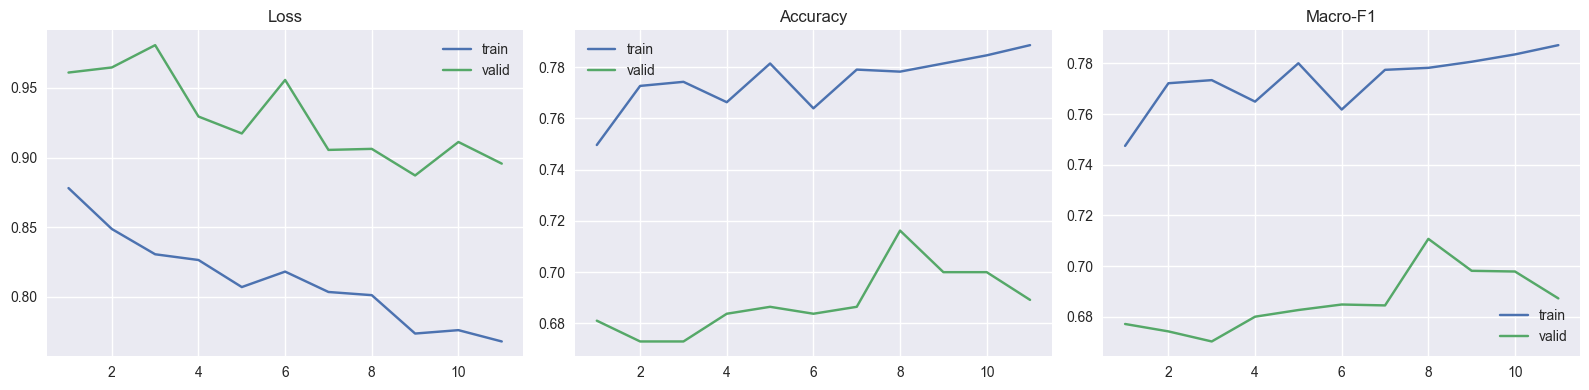

Test accuracy: 0.7814
Test macro-F1: 0.7810

Classification report (test):
                   precision    recall  f1-score   support

      Demodicosis       0.81      0.84      0.83        31
       Dermatitis       0.82      0.74      0.78        31
Fungal_infections       0.90      0.62      0.73        29
          Healthy       0.91      0.97      0.94        31
 Hypersensitivity       0.56      0.76      0.65        29
         Ringworm       0.77      0.75      0.76        32

         accuracy                           0.78       183
        macro avg       0.80      0.78      0.78       183
     weighted avg       0.80      0.78      0.78       183



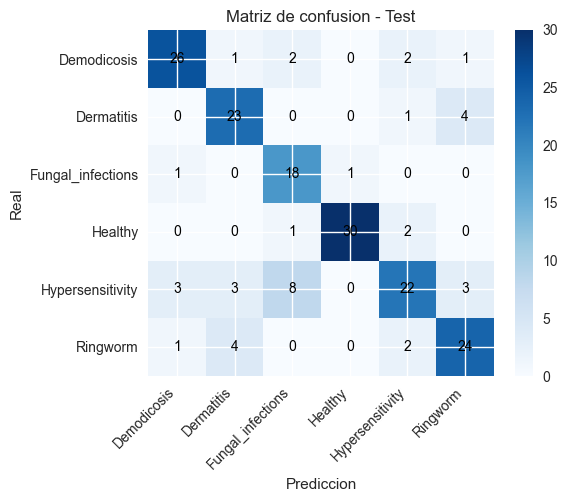

In [33]:
plot_history(hist_Resnet18)
test_preds_resnet18, test_targets_resnet18 = predicts(model_resnet18_mod)
matriz_confusion(test_preds_resnet18, test_targets_resnet18)

## Prueba para Cargar los Modelos 

In [ ]:
carga_model_efficientNet_mod = build_efficientnet_b0(num_classes).to(device)


#freeze_backbone(model_efficientNet_mod)
#model_efficientNet_mod

In [ ]:
#directorio principal de las imagenes
DATA_DIR = Path("Dog's skin diseases-Kaggle_v_corta")
# redimncion de las imagenes
IMAGE_SIZE = (256,256)
#Tamaño del batch
BATCH_SIZE = 32

transform_train = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.1, hue=0.05),
    transforms.RandomRotation(46),
    #T.CenterCrop(256),
    transforms.RandomApply([transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)), transforms.CenterCrop(256)], p=0.5),
    #T.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std= [0.5,0.5,0.5]),
    ])

transform_general = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std= [0.5,0.5,0.5]),
])

train_dataset = datasets.ImageFolder(DATA_DIR / 'train', transform=transform_train)
val_dataset = datasets.ImageFolder(DATA_DIR / 'valid', transform=transform_general)
test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=transform_general)



train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

In [39]:
def carga_efficientnet_b0(num_classes):
    #weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    #model = models.mobilenet_v3_small(weights=weights)
    model_efficientnet_b0 = models.efficientnet_b0(pretrained=False)
    in_features = model_efficientnet_b0.classifier[-1].in_features
    model_efficientnet_b0.classifier[-1] = nn.Linear(in_features, num_classes)
    pesos = torch.load('models/model_EfficientNet.pth', map_location=torch.device('cpu'))
    model_efficientnet_b0.load_state_dict(pesos)

    return model_efficientnet_b0

carga_model_efficientnet_b0_mod = carga_efficientnet_b0(num_classes).to(device)
#freeze_backbone(carga_model_efficientnet_b0_mod)

c:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
carga_model_efficientnet_b0_mod.eval()

In [40]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis=('off')
    plt.show()

In [41]:
#test_loader.dataset[0]
def sample_image():
    rnd_indx = np.random.randint(100)
    image = test_loader.dataset[rnd_indx]
    plot_number(image)
    return torch.tensor(image).to(device = device , dtype = torch.float).view(1,784)

Test accuracy: 0.7596
Test macro-F1: 0.7519

Classification report (test):
                   precision    recall  f1-score   support

      Demodicosis       0.88      0.90      0.89        31
       Dermatitis       0.72      0.68      0.70        31
Fungal_infections       0.68      0.72      0.70        29
          Healthy       0.83      0.97      0.90        31
 Hypersensitivity       0.65      0.52      0.58        29
         Ringworm       0.75      0.75      0.75        32

         accuracy                           0.76       183
        macro avg       0.75      0.76      0.75       183
     weighted avg       0.75      0.76      0.75       183



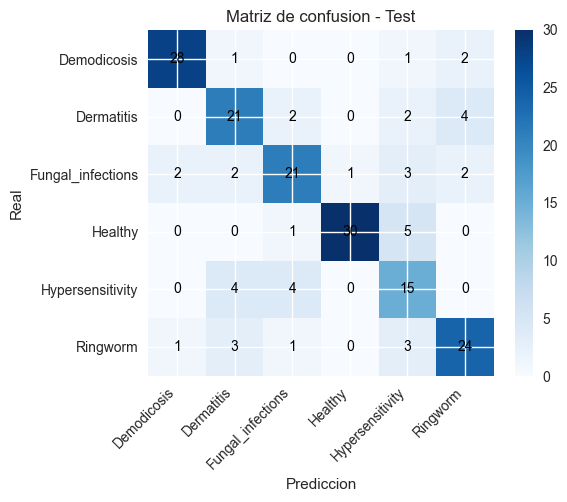

In [42]:

test_preds_E, test_targets_E = predicts(carga_model_efficientnet_b0_mod)
matriz_confusion(test_preds_E, test_targets_E)

## Experimentos

In [37]:
from PIL import Image
import os
import glob

In [38]:
def imagenes_aleatorias(n):
    imagenes_A = []
    for i in range(n):
        carpeta_base = "Dog's skin diseases-Kaggle_v_corta/test"

        # Definir patrones para múltiples extensiones
        # El operador ** busca recursivamente en todos los subdirectorios
        patrones = [
            os.path.join(carpeta_base, '**/*.jpg'),
            os.path.join(carpeta_base, '**/*.jpeg'),
            os.path.join(carpeta_base, '**/*.png'),
            os.path.join(carpeta_base, '**/*.bmp')
        ]

        # Recopilar todas las rutas de imágenes en una sola lista
        # Usamos set() para evitar duplicados si hubiera coincidencias extrañas
        todas_las_imagenes = []
        for patron in patrones:
            todas_las_imagenes.extend(glob.glob(patron, recursive=True))

        if not todas_las_imagenes:
            raise FileNotFoundError("No se encontraron imágenes en la carpeta ni en sus subcarpetas.")

        # Elegir una al azar
        ruta_elegida = random.choice(todas_las_imagenes)
        imagenes_A.append(ruta_elegida)
    return imagenes_A    

In [ ]:
im_A = imagenes_aleatorias(4)
im_A

In [43]:
def build_input_from_pil(pil_img: Image.Image):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    rgb_img = np.array(pil_img.resize((224, 224)), dtype=np.float32) / 255.0
    input_tensor = transform(pil_img).unsqueeze(0)
    return rgb_img, input_tensor

In [44]:
# Sin recorte: entrada directa con imagen completa
pil_img_full = Image.open(Path("Dog's skin diseases-Kaggle_v_corta/test/Dermatitis/1000010494_x16_jpg.rf.ea6148c3096cad322d093d8c9202b9cd.jpg")).convert("RGB")
rgb_img, input_tensor = build_input_from_pil(pil_img_full)
input_tensor = input_tensor.to(device)

In [35]:
# Librerías de explicabilidad (Grad-CAM)
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

## carga Resnet18


In [65]:
prueba_EfficientNet = models.efficientnet_b0(pretrained=True)
prueba_EfficientNet

c:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [62]:
carga_model_resnet18 = models.resnet18(pretrained=False)
carga_model_aux = nn.Sequential(*list(carga_model_resnet18.children())[:-1])
for i, parameter in enumerate(model_aux.parameters()):
  parameter.requires_grad = False

carga_model_resnet18_mod = nn.Sequential(carga_model_aux,
                       nn.Flatten(),
                       nn.Linear(in_features=512, out_features=5, bias= True))  

c:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [64]:
#pesos = torch.load('models/Resnet18_mod.pth', map_location=torch.device('cpu'))
#carga_model_resnet18_mod.load_state_dict(pesos)

In [45]:
#carga_model_efficientnet_b0_mod
with torch.no_grad():
    logits = carga_model_efficientnet_b0_mod(input_tensor)
    probs = torch.softmax(logits, dim=1)
    pred_class_idx = int(torch.argmax(probs, dim=1).item())
    pred_conf = float(probs[0, pred_class_idx].item())

pred_class_name = class_names[pred_class_idx]
targets = [ClassifierOutputTarget(pred_class_idx)]

print(f"Clase predicha: {pred_class_name} ({pred_conf*100:.2f}%)")

Clase predicha: Dermatitis (84.75%)


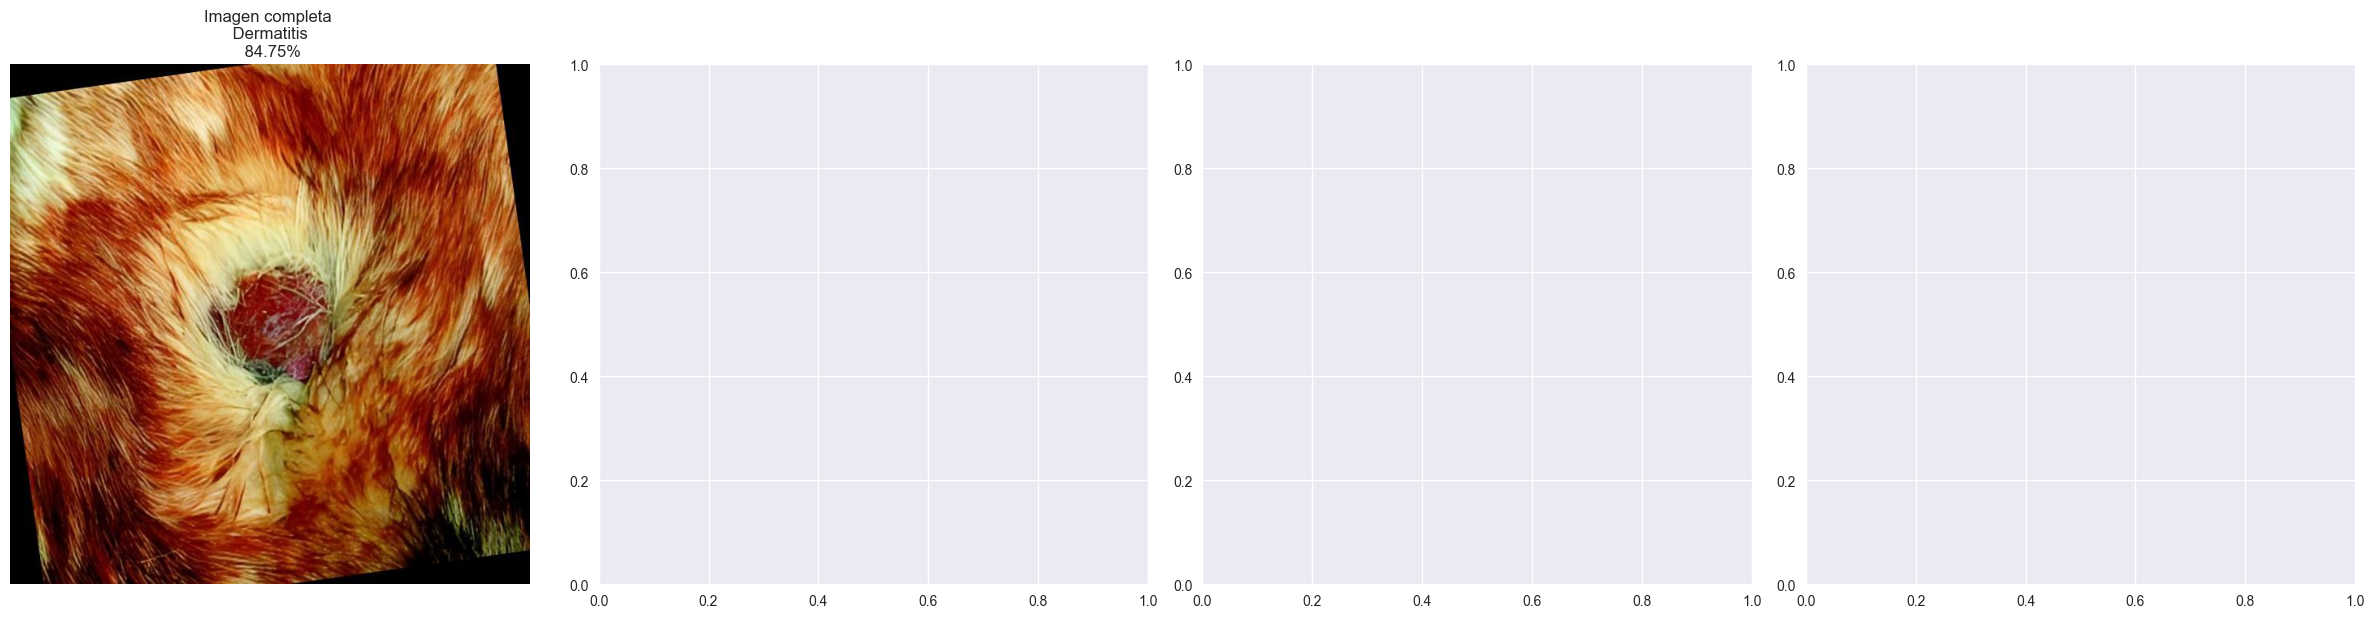

In [46]:
# Columna 0: Entrada original
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(pil_img_full)
axes[0].set_title(f"Imagen completa \n {pred_class_name} \n {pred_conf*100:.2f}%")
axes[0].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def mostrar_imagens(n):
    im_A = imagenes_aleatorias(n)
    fig, axes = plt.subplots(1, n, figsize=(24, 6))

    for i in range(n):
        pil_img_full = Image.open(Path(im_A[i])).convert("RGB")
        rgb_img, input_tensor = build_input_from_pil(pil_img_full)
        input_tensor = input_tensor.to(device)
        
        with torch.no_grad():
            logits = carga_model_efficientnet_b0_mod(input_tensor)
            probs = torch.softmax(logits, dim=1)
            pred_class_idx = int(torch.argmax(probs, dim=1).item())
            pred_conf = float(probs[0, pred_class_idx].item())

        pred_class_name = class_names[pred_class_idx]
        targets = [ClassifierOutputTarget(pred_class_idx)]

        axes[i].imshow(pil_img_full)
        axes[i].set_title(f"Imagen {i} \n {pred_class_name} \n {pred_conf*100:.2f}%")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
    print(im_A)


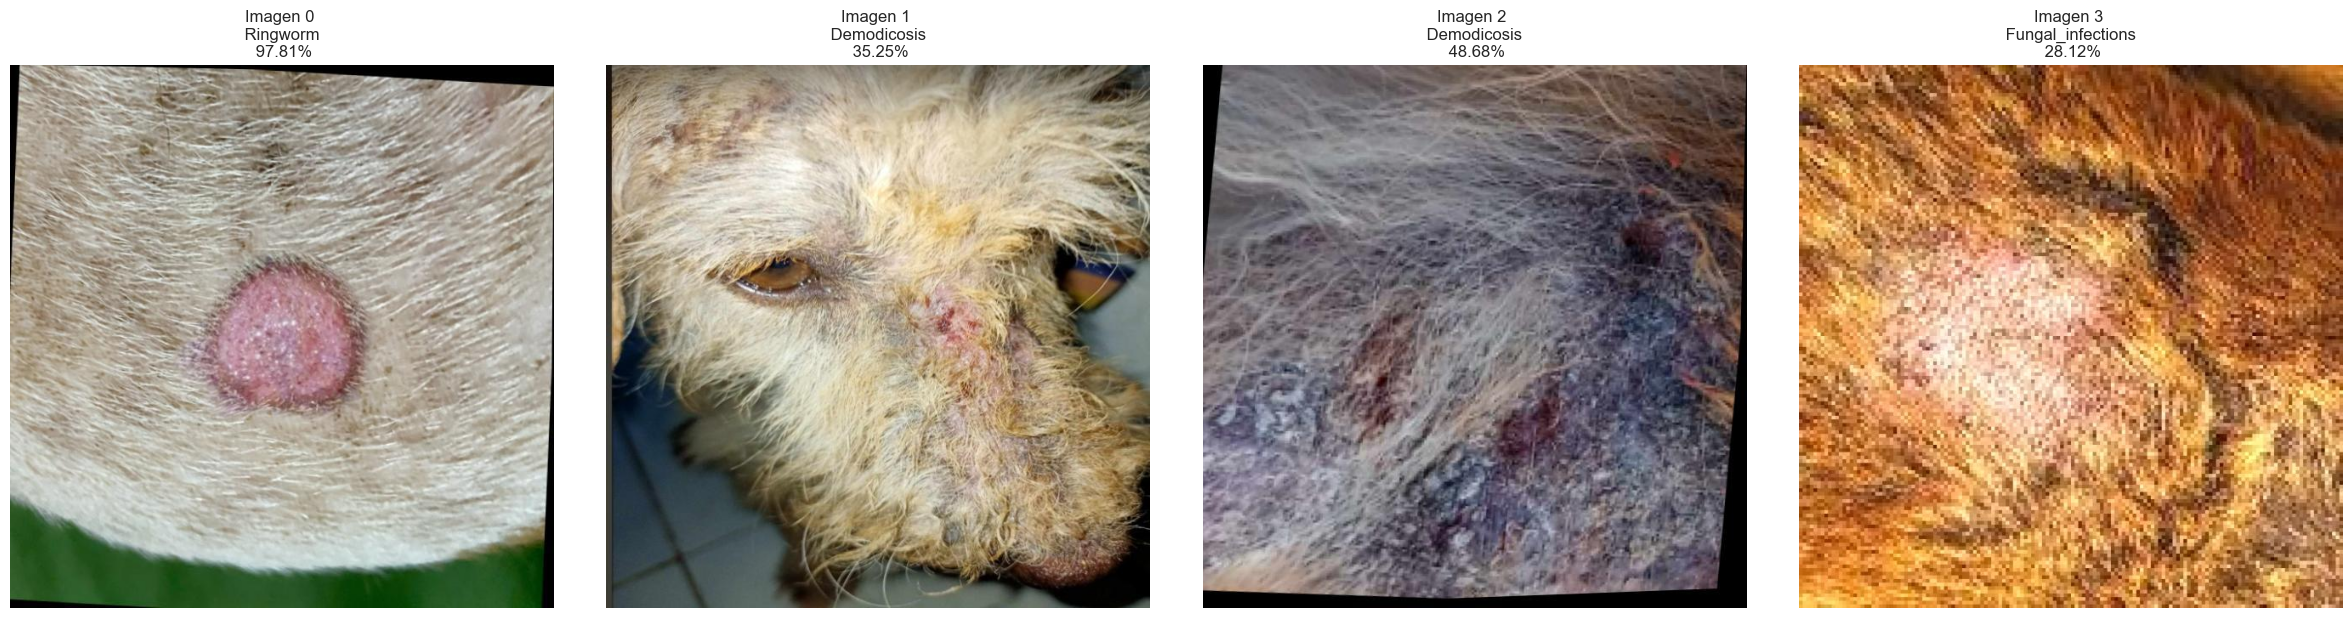

["Dog's skin diseases-Kaggle_v_corta/test\\Ringworm\\NEWR24_png_jpg.rf.9cc922b08f48dc72257ad3c4b9c3e9b3.jpg", "Dog's skin diseases-Kaggle_v_corta/test\\Demodicosis\\P22_png_jpg.rf.0c8268907171bddae0f1975f0c66b96e.jpg", "Dog's skin diseases-Kaggle_v_corta/test\\Demodicosis\\1-44-_png_jpg.rf.4d021276893f273a628c0078a2801dd2.jpg", "Dog's skin diseases-Kaggle_v_corta/test\\Fungal_infections\\FUNGAL-INFECTION_007_jpg.rf.2b0e0aad14c7b26bc0aca0f2bd6e8d79.jpg"]


In [50]:
mostrar_imagens(4)

In [55]:
from pathlib import Path

def find_weights_path() -> Path:
    """Busca los pesos de ResNet18 en ubicaciones comunes del proyecto."""
    candidates = [
        Path("../models/Resnet18_mod.pth"),
        Path("./models/Resnet18_mod.pth"),
        Path.cwd() / "models/Resnet18_mod.pth",
        Path.cwd().parent / "models/Resnet18_mod.pth",
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError(
        "No se encontró Resnet18_mod.pth. Debe estar en la raíz del proyecto."
    )

def build_input_from_pil(pil_img: Image.Image):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    rgb_img = np.array(pil_img.resize((224, 224)), dtype=np.float32) / 255.0
    input_tensor = transform(pil_img).unsqueeze(0)
    return rgb_img, input_tensor

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

weights_path = find_weights_path()

Usando dispositivo: cpu


In [58]:
preferred_image_candidates = [
    Path("Dog's skin diseases-Kaggle_v_corta/test/Dermatitis/Atopic-dermatitis_Dog-chronic-lick-sore-on-leg_DermVets_jpg.rf.e3f4c6fcb1f3dbf3f44e1ef209b12004.jpg"),
    Path("Roya 1001.jpg"),
]

image_path = None
for candidate in preferred_image_candidates:
    if candidate.exists():
        image_path = candidate.resolve()
        break

if image_path is None:
    raise FileNotFoundError(
        "No se encontró 'Roya 1001.jpg' en la raíz del proyecto."
    )

print(f"Pesos usados: {weights_path}")
print(f"Imagen usada: {image_path}")

Pesos usados: C:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\models\Resnet18_mod.pth
Imagen usada: C:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\Dog's skin diseases-Kaggle_v_corta\test\Dermatitis\Atopic-dermatitis_Dog-chronic-lick-sore-on-leg_DermVets_jpg.rf.e3f4c6fcb1f3dbf3f44e1ef209b12004.jpg


In [60]:
# Sin recorte: entrada directa con imagen completa
pil_img_full = Image.open(image_path).convert("RGB")
rgb_img, input_tensor = build_input_from_pil(pil_img_full)
input_tensor = input_tensor.to(device)

#cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#num_ftrs = cnn_model.fc.in_features
#cnn_model.fc = torch.nn.Linear(num_ftrs, 6)
#cnn_model.load_state_dict(torch.load(weights_path, map_location=device))
#cnn_model = cnn_model.to(device)
#cnn_model.eval()
carga_model_efficientnet_b0_mod.eval()

class_names = ['Demodicosis', 'Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'Ringworm']

with torch.no_grad():
    logits = carga_model_efficientnet_b0_mod(input_tensor)
    probs = torch.softmax(logits, dim=1)
    pred_class_idx = int(torch.argmax(probs, dim=1).item())
    pred_conf = float(probs[0, pred_class_idx].item())

pred_class_name = class_names[pred_class_idx]
targets = [ClassifierOutputTarget(pred_class_idx)]

print(f"Clase predicha: {pred_class_name} ({pred_conf*100:.2f}%)")

Clase predicha: Dermatitis (53.26%)


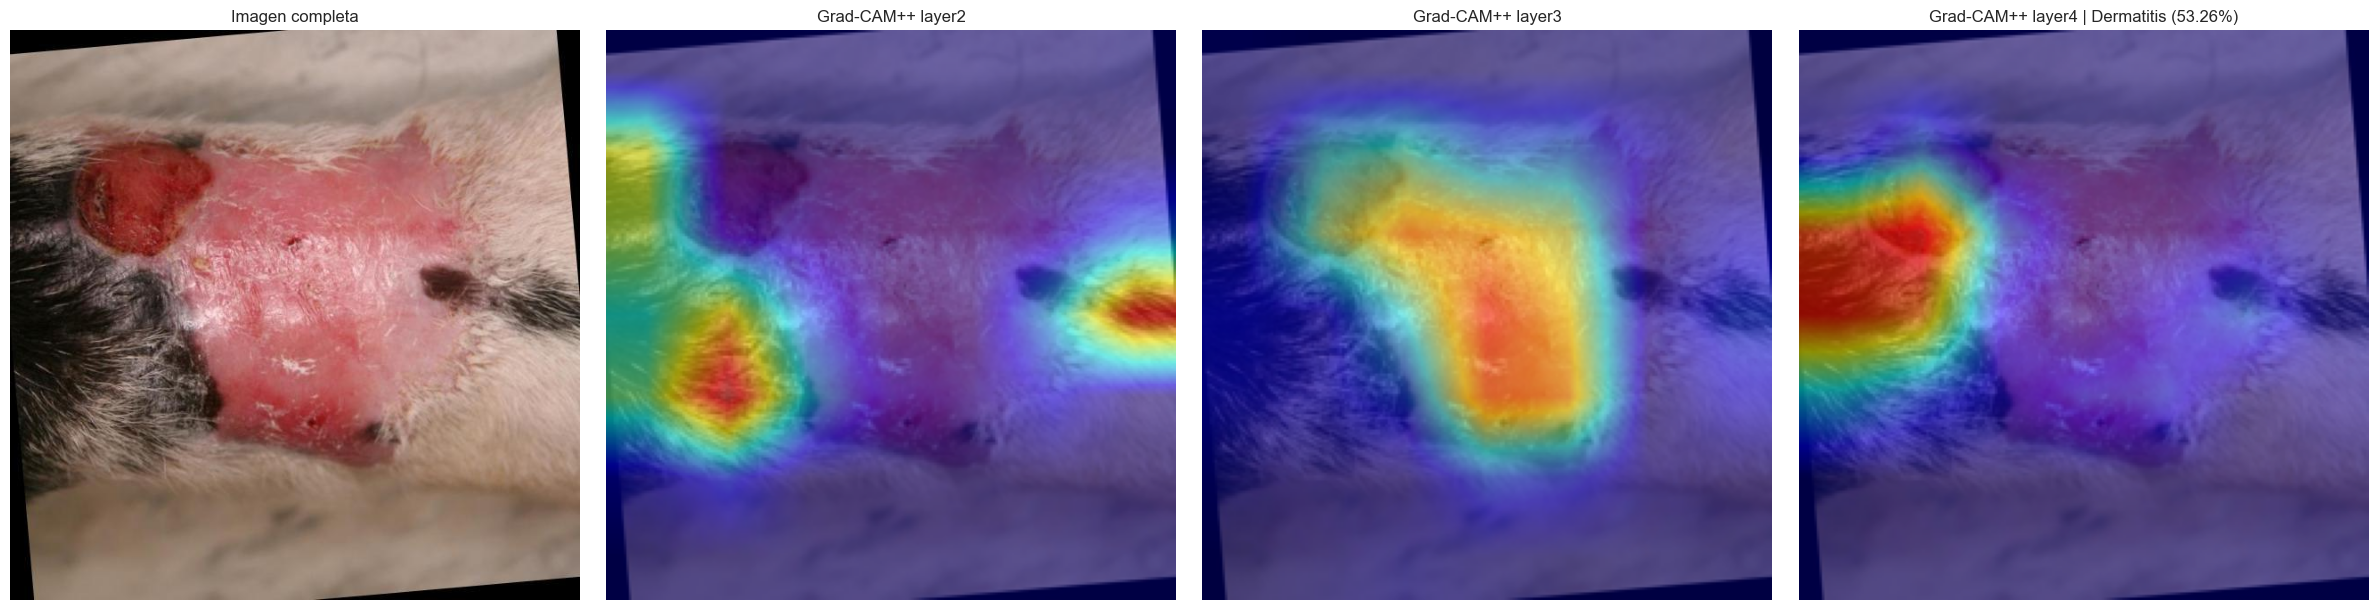

In [68]:
import matplotlib.pyplot as plt

# 1. Instanciar los objetos Grad-CAM++ para cada capa (añadiendo layer4)
cam_layer4 = GradCAMPlusPlus(model=carga_model_efficientnet_b0_mod, target_layers=[carga_model_efficientnet_b0_mod.features[-1]])
cam_layer3 = GradCAMPlusPlus(model=carga_model_efficientnet_b0_mod, target_layers=[carga_model_efficientnet_b0_mod.features[-2]])
cam_layer2 = GradCAMPlusPlus(model=carga_model_efficientnet_b0_mod, target_layers=[carga_model_efficientnet_b0_mod.features[-3]])

# 2. Calcular las activaciones con suavizado
cam_gcpp_l4 = cam_layer4(
    input_tensor=input_tensor,
    targets=targets,
    aug_smooth=True,
    eigen_smooth=True,
)[0, :]

cam_gcpp_l3 = cam_layer3(
    input_tensor=input_tensor,
    targets=targets,
    aug_smooth=True,
    eigen_smooth=True,
)[0, :]

cam_gcpp_l2 = cam_layer2(
    input_tensor=input_tensor,
    targets=targets,
    aug_smooth=True,
    eigen_smooth=True,
)[0, :]

# 3. Mezclar los mapas de calor con la imagen original en formato RGB
vis_l4 = show_cam_on_image(rgb_img, cam_gcpp_l4, use_rgb=True)
vis_l3 = show_cam_on_image(rgb_img, cam_gcpp_l3, use_rgb=True)
vis_l2 = show_cam_on_image(rgb_img, cam_gcpp_l2, use_rgb=True)

# 4. Configurar el plot (Cambiamos a 1 fila y 4 columnas, ajustando el figsize)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Columna 0: Entrada original
axes[0].imshow(pil_img_full)
axes[0].set_title("Imagen completa")
axes[0].axis('off')

# Columna 1: Características de nivel medio
axes[1].imshow(vis_l2)
axes[1].set_title("Grad-CAM++ layer2")
axes[1].axis('off')

# Columna 2: Características de nivel alto / semántico
axes[2].imshow(vis_l3)
axes[2].set_title("Grad-CAM++ layer3")
axes[2].axis('off')

# Columna 3: Características finales + Clasificación (Capa más profunda)
axes[3].imshow(vis_l4)
axes[3].set_title(f"Grad-CAM++ layer4 | {pred_class_name} ({pred_conf*100:.2f}%)")
axes[3].axis('off')

plt.tight_layout()
plt.show()